# 逻辑回归（Logistic Regression）

逻辑回归是一种用于**分类**任务的监督学习算法（名字里有「回归」但本质做分类）。

核心思想：在线性回归的基础上，用 **Sigmoid 函数**将输出压缩到 $(0,1)$ 区间，作为样本属于某类别的**概率**。

## 1. 从线性回归到逻辑回归

线性回归：$\hat{y} = w^T x + b$，输出范围 $(-\infty, +\infty)$，不适合直接做分类。

逻辑回归：在线性输出外套一个 Sigmoid 函数：

$$\hat{p} = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

- $\hat{p} > 0.5$ → 预测为正类（1）
- $\hat{p} \leq 0.5$ → 预测为负类（0）
- 决策边界就是 $w^T x + b = 0$ 这条（超）平面

## 2. Sigmoid 函数

C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2056462108.py:19: UserWarning: Glyph 20989 (\N{CJK UNIFIED IDEOGRAPH-51FD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2056462108.py:19: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2056462108.py:19: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2056462108.py:19: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2056462108.py:19: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2056462108.py:19: UserWarning: Glyph 30028 (\

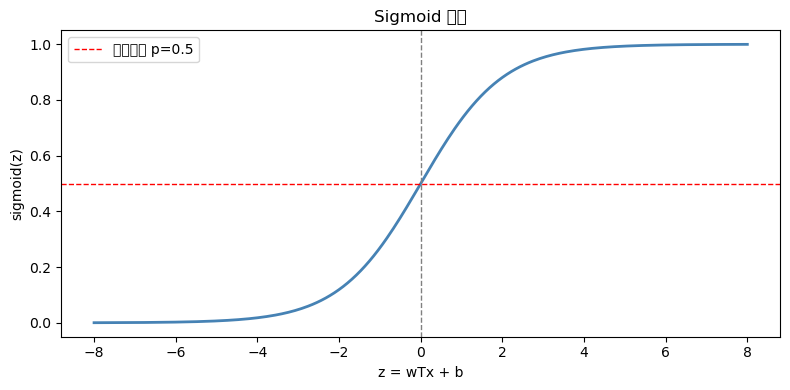

sigmoid(-8) = 0.000335  -> 接近 0
sigmoid( 0) = 0.500000  -> 恰好 0.5
sigmoid( 8) = 0.999665  -> 接近 1


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)
s = sigmoid(z)

plt.figure(figsize=(8, 4))
plt.plot(z, s, color='steelblue', linewidth=2)
plt.axhline(0.5, color='red', linestyle='--', linewidth=1, label='决策边界 p=0.5')
plt.axvline(0,   color='gray', linestyle='--', linewidth=1)
plt.xlabel('z = wTx + b')
plt.ylabel('sigmoid(z)')
plt.title('Sigmoid 函数')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print(f"sigmoid(-8) = {sigmoid(-8):.6f}  -> 接近 0")
print(f"sigmoid( 0) = {sigmoid(0):.6f}  -> 恰好 0.5")
print(f"sigmoid( 8) = {sigmoid(8):.6f}  -> 接近 1")

## 3. 损失函数：对数损失（Log Loss / 交叉熵）

不能用 MSE，因为 Sigmoid 套上 MSE 会产生**非凸**损失面，梯度下降容易陷入局部极小值。

逻辑回归使用**对数损失（Binary Cross-Entropy）**：

$$\mathcal{L}(y, \hat{p}) = -[y \log \hat{p} + (1-y) \log(1-\hat{p})]$$

- 当 $y=1$：损失 $= -\log\hat{p}$，预测概率越高损失越小
- 当 $y=0$：损失 $= -\log(1-\hat{p})$，预测概率越低损失越小

整个训练集的平均损失：

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{p}^{(i)} + (1-y^{(i)}) \log(1-\hat{p}^{(i)}) \right]$$

C:\Users\28390\AppData\Local\Temp\ipykernel_62612\3012911277.py:14: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\3012911277.py:14: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\3012911277.py:14: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\3012911277.py:14: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\3012911277.py:14: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\3012911277.py:14: UserWarning: Glyph 22833 (\

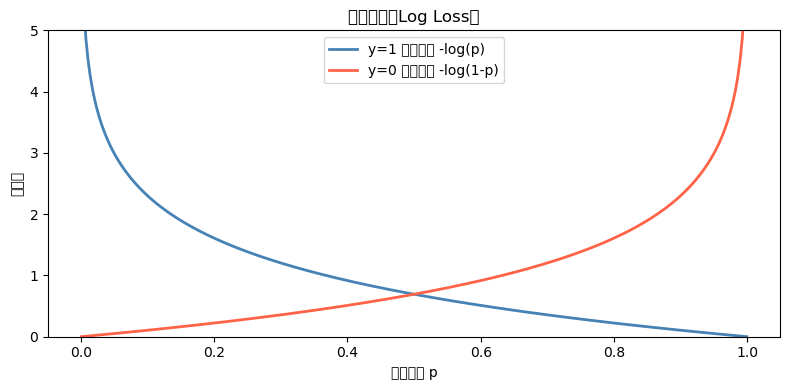

In [12]:
p = np.linspace(0.001, 0.999, 300)

loss_y1 = -np.log(p)       # 真实标签 y=1
loss_y0 = -np.log(1 - p)   # 真实标签 y=0

plt.figure(figsize=(8, 4))
plt.plot(p, loss_y1, label='y=1 时的损失 -log(p)',   color='steelblue', linewidth=2)
plt.plot(p, loss_y0, label='y=0 时的损失 -log(1-p)', color='tomato',    linewidth=2)
plt.xlabel('预测概率 p')
plt.ylabel('损失值')
plt.title('对数损失（Log Loss）')
plt.ylim(0, 5)
plt.legend()
plt.tight_layout()
plt.show()

## 4. 梯度下降求解

对损失函数 $J(w, b)$ 求偏导（推导后形式非常简洁）：

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{p} - y)$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{p}^{(i)} - y^{(i)})$$

参数更新：

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \quad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2256692676.py:34: UserWarning: Glyph 36845 (\N{CJK UNIFIED IDEOGRAPH-8FED}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2256692676.py:34: UserWarning: Glyph 20195 (\N{CJK UNIFIED IDEOGRAPH-4EE3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2256692676.py:34: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2256692676.py:34: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2256692676.py:34: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2256692676.py:34: UserWarning: Glyph 24230 (\

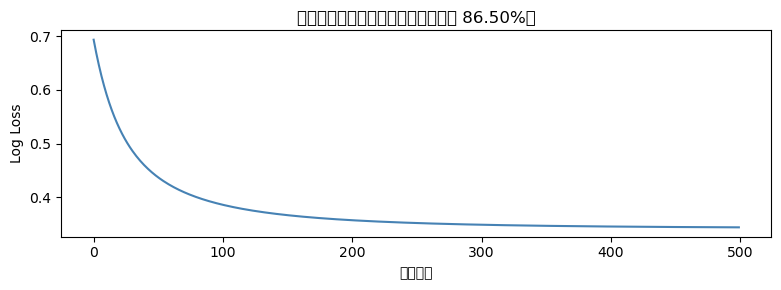

In [13]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X_raw, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                n_informative=2, random_state=42)
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
m, n = X.shape

w = np.zeros(n)
b = 0.0
lr = 0.1
losses = []

for epoch in range(500):
    z      = X @ w + b
    p_hat  = sigmoid(z)
    loss   = -np.mean(y * np.log(p_hat + 1e-9) + (1 - y) * np.log(1 - p_hat + 1e-9))
    losses.append(loss)
    dw = X.T @ (p_hat - y) / m
    db = np.mean(p_hat - y)
    w -= lr * dw
    b -= lr * db

y_pred = (sigmoid(X @ w + b) >= 0.5).astype(int)
acc = np.mean(y_pred == y)

plt.figure(figsize=(8, 3))
plt.plot(losses, color='steelblue')
plt.xlabel('迭代次数')
plt.ylabel('Log Loss')
plt.title(f'梯度下降收敛曲线（最终训练准确率 {acc:.2%}）')
plt.tight_layout()
plt.show()

## 5. 决策边界可视化

C:\Users\28390\AppData\Local\Temp\ipykernel_62612\754633070.py:15: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\754633070.py:15: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\754633070.py:15: UserWarning: Glyph 36923 (\N{CJK UNIFIED IDEOGRAPH-903B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\754633070.py:15: UserWarning: Glyph 36753 (\N{CJK UNIFIED IDEOGRAPH-8F91}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\754633070.py:15: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\754633070.py:15: UserWarning: Glyph 24402 (\N{CJK 

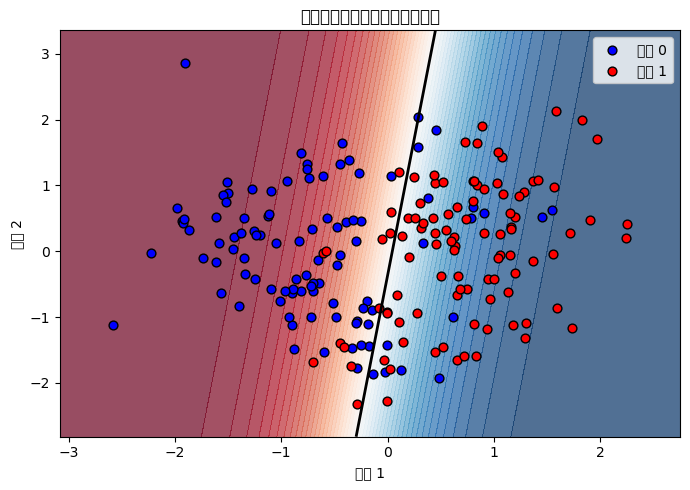

In [14]:
x1_range = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
x2_range = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200)
xx1, xx2  = np.meshgrid(x1_range, x2_range)
Z = sigmoid(np.c_[xx1.ravel(), xx2.ravel()] @ w + b).reshape(xx1.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx1, xx2, Z, levels=50, cmap='RdBu', alpha=0.7)
plt.contour(xx1, xx2, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', edgecolors='k', s=40, label='类别 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red',  edgecolors='k', s=40, label='类别 1')
plt.xlabel('特征 1')
plt.ylabel('特征 2')
plt.title('逻辑回归决策边界（手动实现）')
plt.legend()
plt.tight_layout()
plt.show()

## 6. 正则化（防止过拟合）

正则化在损失函数中加入惩罚项，限制参数 $w$ 过大：

**L2 正则化（Ridge）**：
$$J_{L2} = J + \frac{\lambda}{2m} \|w\|_2^2$$

**L1 正则化（Lasso）**：
$$J_{L1} = J + \frac{\lambda}{m} \|w\|_1$$

| 正则化 | 效果 | sklearn 参数 |
|--------|------|-------------|
| L2（默认） | 使权重整体缩小，保留所有特征 | `penalty='l2'` |
| L1 | 使部分权重变为 0，自动特征选择 | `penalty='l1'` |
| 无正则化 | 容易过拟合 | `penalty=None` |

`C` 参数 = $1/\lambda$，**C 越小正则化越强**。

## 7. sklearn 实现逻辑回归

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.datasets import load_breast_cancer

# 乳腺癌数据集：二分类（良性/恶性）
data = load_breast_cancer()
X_bc, y_bc = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42
)

# 特征标准化（逻辑回归对特征尺度敏感）
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)

clf = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
clf.fit(X_train_s, y_train)
y_pred = clf.predict(X_test_s)

print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 8. 评估指标详解

混淆矩阵（Confusion Matrix）：

|  | 预测正 | 预测负 |
|--|--------|--------|
| **实际正** | TP（真正例） | FN（假负例） |
| **实际负** | FP（假正例） | TN（真负例） |

$$\text{准确率} = \frac{TP+TN}{TP+TN+FP+FN}$$

$$\text{精确率（Precision）} = \frac{TP}{TP+FP} \quad \text{（预测为正中有多少真正是正）}$$

$$\text{召回率（Recall）} = \frac{TP}{TP+FN} \quad \text{（实际正例中有多少被找出来）}$$

$$\text{F1} = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2427739585.py:11: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2427739585.py:11: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2427739585.py:11: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2427739585.py:11: UserWarning: Glyph 31614 (\N{CJK UNIFIED IDEOGRAPH-7B7E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2427739585.py:11: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\2427739585.py:11: UserWarning: Glyph 23454 (\

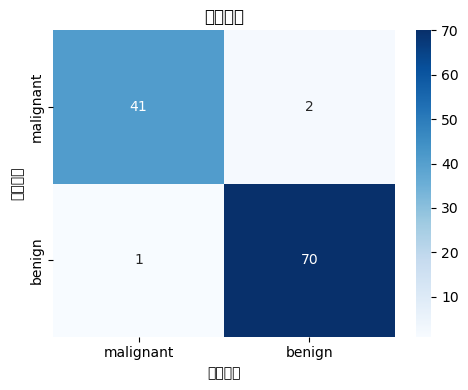

准确率  Accuracy  = 0.9737
精确率  Precision = 0.9722
召回率  Recall    = 0.9859
F1 分数           = 0.9790


In [16]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('预测标签')
plt.ylabel('真实标签')
plt.title('混淆矩阵')
plt.tight_layout()
plt.show()

print(f"准确率  Accuracy  = {accuracy_score(y_test, y_pred):.4f}")
print(f"精确率  Precision = {precision_score(y_test, y_pred):.4f}")
print(f"召回率  Recall    = {recall_score(y_test, y_pred):.4f}")
print(f"F1 分数           = {f1_score(y_test, y_pred):.4f}")

## 9. ROC 曲线与 AUC

ROC 曲线通过调节分类阈值，绘制 **TPR（召回率）vs FPR** 的曲线：

$$TPR = \frac{TP}{TP+FN}, \quad FPR = \frac{FP}{FP+TN}$$

**AUC（Area Under Curve）**：ROC 曲线下的面积，范围 $[0,1]$。
- AUC = 1.0：完美分类器
- AUC = 0.5：随机猜测（对角线）
- AUC < 0.5：比随机还差（相当于预测反了）

C:\Users\28390\AppData\Local\Temp\ipykernel_62612\216377593.py:14: UserWarning: Glyph 20551 (\N{CJK UNIFIED IDEOGRAPH-5047}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\216377593.py:14: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\216377593.py:14: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\216377593.py:14: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\216377593.py:14: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\216377593.py:14: UserWarning: Glyph 32447 (\N{CJK 

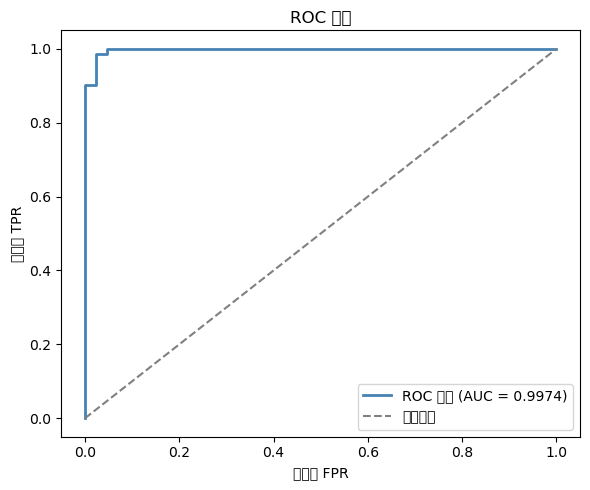

AUC = 0.9974


In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = clf.predict_proba(X_test_s)[:, 1]  # 取正类概率
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'ROC 曲线 (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='随机猜测')
plt.xlabel('假正率 FPR')
plt.ylabel('真正率 TPR')
plt.title('ROC 曲线')
plt.legend()
plt.tight_layout()
plt.show()
print(f"AUC = {auc:.4f}")

## 10. 多分类逻辑回归

逻辑回归扩展到多分类有两种策略：

**OvR（One-vs-Rest）**：训练 $K$ 个二分类器，每个「当前类 vs 其余所有类」。

**Softmax（多项式逻辑回归）**：直接输出 $K$ 个类别的概率，所有概率之和为 1：

$$P(y=k|x) = \frac{e^{w_k^T x + b_k}}{\sum_{j=1}^{K} e^{w_j^T x + b_j}}$$

In [18]:
from sklearn.datasets import load_iris
from sklearn.multiclass import OneVsRestClassifier

iris = load_iris()
X_ir, y_ir = iris.data, iris.target
X_tr, X_te, y_tr, y_te = train_test_split(X_ir, y_ir, test_size=0.2, random_state=42)
sc2 = StandardScaler()
X_tr_s = sc2.fit_transform(X_tr)
X_te_s  = sc2.transform(X_te)

# OvR：用 OneVsRestClassifier 包装（multi_class 参数在 sklearn 1.5+ 已移除）
ovr     = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=1000))
# Softmax：lbfgs solver 多分类默认即 multinomial
softmax = LogisticRegression(solver='lbfgs', max_iter=1000)
ovr.fit(X_tr_s, y_tr)
softmax.fit(X_tr_s, y_tr)

print(f"OvR      准确率: {accuracy_score(y_te, ovr.predict(X_te_s)):.4f}")
print(f"Softmax  准确率: {accuracy_score(y_te, softmax.predict(X_te_s)):.4f}")
print()
proba = softmax.predict_proba(X_te_s[:5])
print("Softmax 概率输出（前5个测试样本）：")
print(f"{'样本':<5} {'setosa':>10} {'versicolor':>12} {'virginica':>10}")
for i, row in enumerate(proba):
    print(f"{i+1:<5} {row[0]:>10.4f} {row[1]:>12.4f} {row[2]:>10.4f}")

OvR      准确率: 0.9667
Softmax  准确率: 1.0000

Softmax 概率输出（前5个测试样本）：
样本        setosa   versicolor  virginica
1         0.0115       0.8760     0.1126
2         0.9644       0.0356     0.0000
3         0.0000       0.0029     0.9971
4         0.0132       0.7594     0.2274
5         0.0019       0.7521     0.2460


## 11. 正则化强度对比实验

C:\Users\28390\AppData\Local\Temp\ipykernel_62612\1364570116.py:17: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\1364570116.py:17: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\1364570116.py:17: UserWarning: Glyph 21017 (\N{CJK UNIFIED IDEOGRAPH-5219}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\1364570116.py:17: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\1364570116.py:17: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\28390\AppData\Local\Temp\ipykernel_62612\1364570116.py:17: UserWarning: Glyph 24230 (\

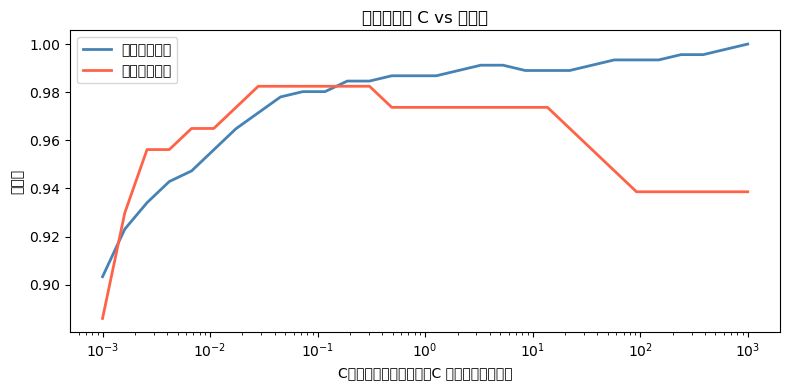

In [ ]:
C_values = np.logspace(-3, 3, 30)  # 从 0.001 到 1000
train_accs, test_accs = [], []

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    model.fit(X_train_s, y_train)
    train_accs.append(accuracy_score(y_train, model.predict(X_train_s)))
    test_accs.append(accuracy_score(y_test,   model.predict(X_test_s)))

plt.figure(figsize=(8, 4))
plt.semilogx(C_values, train_accs, label='训练集准确率', color='steelblue', linewidth=2)
plt.semilogx(C_values, test_accs,  label='测试集准确率', color='tomato',    linewidth=2)
plt.xlabel('C（正则化强度的倒数，C 越小正则化越强）')
plt.ylabel('准确率')
plt.title('正则化强度 C vs 准确率')
plt.legend()
plt.tight_layout()
plt.show()

## 总结

| 知识点 | 核心内容 |
|--------|----------|
| 模型本质 | 线性模型 + Sigmoid，输出为概率 |
| 决策边界 | $w^T x + b = 0$，线性边界 |
| 损失函数 | 对数损失（交叉熵），凸函数，梯度下降可全局收敛 |
| 正则化 | L2（默认）缩小权重；L1 产生稀疏权重；`C=1/lambda` |
| 评估指标 | 准确率、精确率、召回率、F1、AUC-ROC |
| 多分类 | OvR（K 个二分类器）或 Softmax（直接多分类） |

**适用场景：**
- 二分类：垃圾邮件检测、疾病诊断、信用风险评估
- 优点：速度快、可解释性强、输出概率、支持正则化
- 局限：只能处理线性可分问题，非线性场景需要特征工程或换模型（SVM、树模型）